# Linear Regression

**Linear Regression** is a linear model, e.g. a model that assumes a linear relationship between the input variables `(x)` and the single output variable `(y)`. More specifically, that output variable `(y)` can be calculated from a linear combination of the input variables `(x)`.

**Import Dependencies**

## Univariate Linear Regression

Is a linear regression that has only one input parameter and one output label.


- Demo Project: In this demo we will build a model that will predict `Happiness.Score` for the countries based on `Economy.GDP.per.Capita` parameter.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import custom linear regression implementation.
from linear_regression import LinearRegression

In [2]:
data = pd.read_csv('world-happiness-report-2017.csv')
data.head(10)

,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182
5,Netherlands,6,7.377,7.427426,7.326574,1.503945,1.428939,0.810696,0.585384,0.470490,0.282662,2.294804
6,Canada,7,7.316,7.384403,7.247597,1.479204,1.481349,0.834558,0.611101,0.435540,0.287372,2.187264
7,New Zealand,8,7.314,7.379510,7.248490,1.405706,1.548195,0.816760,0.614062,0.500005,0.382817,2.046456
8,Sweden,9,7.284,7.344095,7.223905,1.494387,1.478162,0.830875,0.612924,0.385399,0.384399,2.097538
9,Australia,10,7.284,7.356651,7.211349,1.484415,1.510042,0.843887,0.601607,0.477699,0.301184,2.065211


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        155 non-null    object 
 1   Happiness.Rank                 155 non-null    int64  
 2   Happiness.Score                155 non-null    float64
 3   Whisker.high                   155 non-null    float64
 4   Whisker.low                    155 non-null    float64
 5   Economy..GDP.per.Capita.       155 non-null    float64
 6   Family                         155 non-null    float64
 7   Health..Life.Expectancy.       155 non-null    float64
 8   Freedom                        155 non-null    float64
 9   Generosity                     155 non-null    float64
 10  Trust..Government.Corruption.  155 non-null    float64
 11  Dystopia.Residual              155 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 

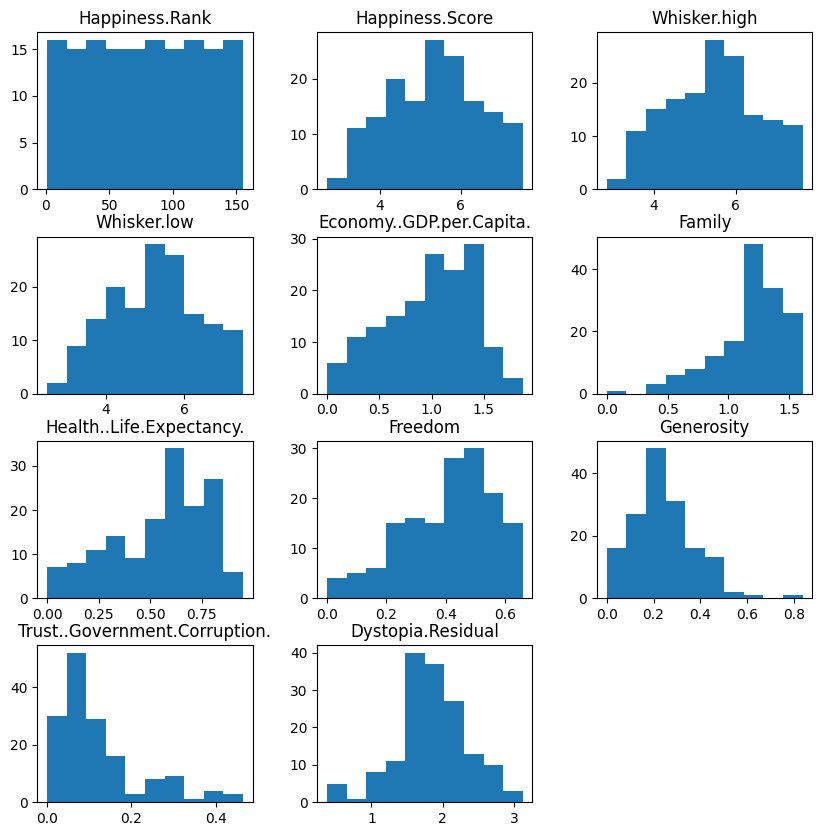

In [4]:
# Print histograms for each feature to see how they vary.
histograms = data.hist(grid=False, figsize=(10,10))

**Split the Data Into Training and Test Subsets**

In this step we will split our dataset into training and testing subsets (in proportion 80/20%).

All data from testing dataset will be new to model and we may check how accurate are model predictions.

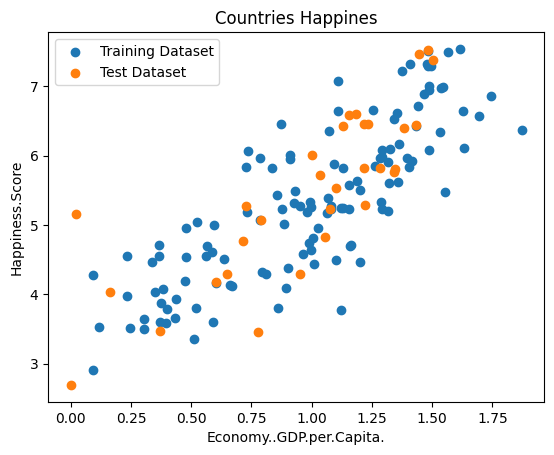

In [5]:
# Function sample() returns a random sample of items.
train_data = data.sample(frac=0.8)
test_data = data.drop(train_data.index)

# Decide what fields we want to process.
input_param_name = 'Economy..GDP.per.Capita.'
output_param_name = 'Happiness.Score'

# Split training set input and output.
x_train = train_data[[input_param_name]].values
y_train = train_data[[output_param_name]].values

# Split test set input and output.
x_test = test_data[[input_param_name]].values
y_test = test_data[[output_param_name]].values

# Plot training data.
plt.scatter(x_train, y_train, label='Training Dataset')
plt.scatter(x_test, y_test, label='Test Dataset')
plt.xlabel(input_param_name)
plt.ylabel(output_param_name)
plt.title('Countries Happines')
plt.legend()
plt.show()

**Initialize and Train Linear Regression Model**

- `polynomial_degree` - this parameter will allow you to add additional polynomial features of certain degree. More features - more curved the line will be.
- `num_iterations` - this is the number of iterations that gradient descent algorithm will use to find the minimum of a cost function. Low numbers may prevent gradient descent from reaching the minimum. High numbers will make the algorithm work longer without improving its accuracy.
- `learning_rate` - this is the size of the gradient descent step. Small learning step will make algorithm work longer and will probably require more iterations to reach the minimum of the cost function. Big learning steps may couse missing the minimum and growth of the cost function value with new iterations.
- `regularization_param` - parameter that will fight overfitting. The higher the parameter, the simplier is the model will be.
- `polynomial_degree` - the degree of additional polynomial features (x1^2 * x2, x1^2 * x2^2, ...). This will allow you to curve the predictions.
- `sinusoid_degree` - the degree of sinusoid parameter multipliers of additional features (sin(x), sin(2*x), ...). This will allow you to curve the predictions by adding sinusoidal component to the prediction curve.

In [6]:
# Set up Linear regression parameters.
num_iterations = 500 # Number of gradient descent iterations.
regularization_param = 0 # Helps to fight model overfitting.
learning_rate = 0.01  # The size of the gradient descent step.
polynomial_degree = 0 # The degree of additional polynomial features.
sinusoid_degree = 0 # The degree of sinusoid parameter multipliers of additional features.

# Init linear regression instance.
linear_regression = LinearRegression(x_train, y_train, polynomial_degree, sinusoid_degree)

# Train linear regression
(theta, cost_history) = linear_regression.train(learning_rate, regularization_param, num_iterations)

# Print training results
print('Initial cost: {:.2f}'.format(cost_history[0]))
print('Optimized cost: {:.2f}'.format(cost_history[-1]))

# Print training parameters
theta_table = pd.DataFrame({'Model Parameters': theta.flatten()})
theta_table.head()

Initial cost: 218323.61
Optimized cost: 3187.83


,Model Parameters
0,5.319661
1,0.899189


**Analyze Gradient Descent Progress**

The plot below illustrates how the cost function value changes over each iteration. You should see it decreasing.

In case if cost function value increases it may mean that gradient descent missed the cost function minimum and with each step it goes further away from it. In this case you might want to reduce the learning rate parameter (the size of the gradient step).

From this plot you may also get an understanding of how many iterations you need to get an optimal value of the cost function. In current example you may see that there is no much sense to increase the number of gradient descent iterations over 500 since it will not reduce cost function significantly.

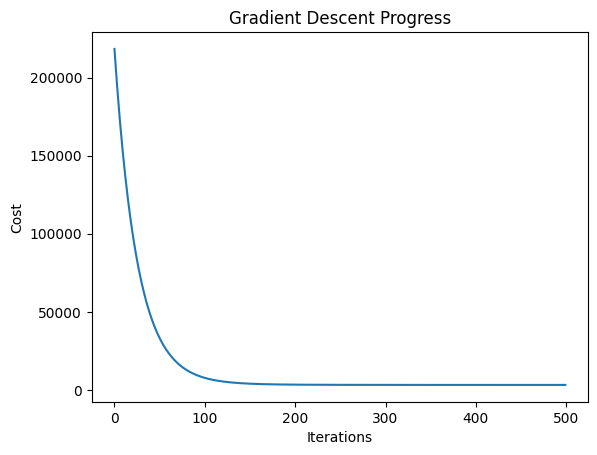

In [7]:
# Plot gradient descent progress.
plt.plot(range(num_iterations), cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Gradient Descent Progress')
plt.show()

**Plot the Model Predictions**

Since our model is trained now we may plot its predictions over the training and test datasets to see how well it fits the data.

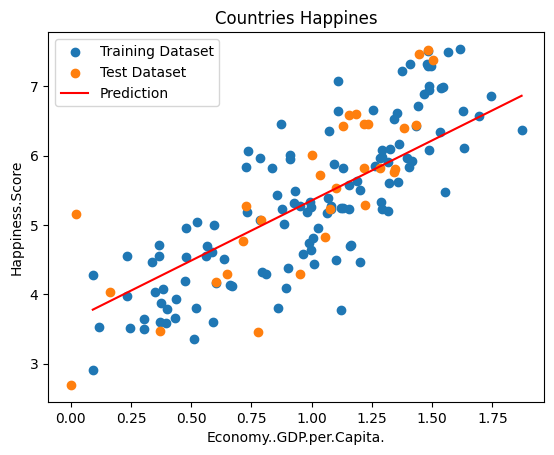

In [8]:
# Get model predictions for the training set.
predictions_num = 100
x_predictions = np.linspace(x_train.min(), x_train.max(), predictions_num).reshape(predictions_num, 1)
y_predictions = linear_regression.predict(x_predictions)

# Plot training data with predictions.
plt.scatter(x_train, y_train, label='Training Dataset')
plt.scatter(x_test, y_test, label='Test Dataset')
plt.plot(x_predictions, y_predictions, 'r', label='Prediction')
plt.xlabel('Economy..GDP.per.Capita.')
plt.ylabel('Happiness.Score')
plt.title('Countries Happines')
plt.legend()
plt.show()

Calculate the value of cost function for the training and test data set. The less this value is, the better.

In [9]:
train_cost = linear_regression.get_cost(x_train, y_train, regularization_param)
test_cost = linear_regression.get_cost(x_test, y_test, regularization_param)

print('Train cost: {:.2f}'.format(train_cost))
print('Test cost: {:.2f}'.format(test_cost))

Train cost: 3187.83
Test cost: 244.40


Let's now render the table of prediction values that our trained model does for unknown data (for test dataset). You should see that predicted happiness score should be quite similar to the known happiness score fron the test dataset.

In [10]:
test_predictions = linear_regression.predict(x_test)

test_predictions_table = pd.DataFrame({
    'Economy GDP per Capita': x_test.flatten(),
    'Test Happiness Score': y_test.flatten(),
    'Predicted Happiness Score': test_predictions.flatten(),
    'Prediction Diff': (y_test - test_predictions).flatten()
})

test_predictions_table.head(10)

,Economy GDP per Capita,Test Happiness Score,Predicted Happiness Score,Prediction Diff
0,1.482383,7.522,6.405259,1.116741
1,1.443572,7.469,6.320148,1.148852
2,1.503945,7.377,6.452542,0.924458
3,1.185295,6.599,5.753762,0.845238
4,1.153184,6.578,5.683343,0.894657
5,1.217560,6.454,5.824516,0.629484
6,1.233748,6.452,5.860017,0.591983
7,1.430923,6.442,6.292411,0.149589
8,1.127869,6.424,5.627829,0.796171
9,1.384398,6.403,6.190383,0.212617


## Multivariate Linear Regression

Is a linear regression that has more than one input parameter and one output label.

- **Demo Project**: In this demo we will build a model that will predict `Happiness.Score` for the countries based on `Economy.GDP.per.Capita` and `Freedom` parameters.

**Import Dependecies**

- We previously imported pandas, numpy, matplotlib and linear_regression. The only dependency we will be adding is plotly. `Plotly` is used to plotting interactive 3D scatters.

In [11]:
import plotly
import plotly.graph_objs as go

**Split the Data Into Training and Test Sets**

In [12]:
# Split data set on training and test sets with proportions 80/20.
# Function sample() returns a random sample of items.
train_data = data.sample(frac=0.8)
test_data = data.drop(train_data.index)

# Decide what fields we want to process.
input_param_1 = 'Economy..GDP.per.Capita.'
input_param_2 = 'Freedom'
output_param = 'Happiness.Score'

# Split training set input and output.
x_train = train_data[[input_param_1, input_param_2]].values
y_train = train_data[[output_param]].values

# Split test set input and output.
x_test = test_data[[input_param_1, input_param_2]].values
y_test = test_data[[output_param]].values

Let's visualize the training and test datasets to see the shape of the data.

In [14]:
# Configure the plot with training dataset.
plot_training_trace = go.Scatter3d(
    x=x_train[:, 0].flatten(),
    y=x_train[:, 1].flatten(),
    z=y_train.flatten(),
    name='Training Set',
    mode='markers',
    marker={
        'size': 10,
        'opacity': 1,
        'line': {
            'color': 'rgb(255, 255, 255)',
            'width': 1
        },
    }
)

# Configure the plot with test dataset.
plot_test_trace = go.Scatter3d(
    x=x_test[:, 0].flatten(),
    y=x_test[:, 1].flatten(),
    z=y_test.flatten(),
    name='Test Set',
    mode='markers',
    marker={
        'size': 10,
        'opacity': 1,
        'line': {
            'color': 'rgb(255, 255, 255)',
            'width': 1
        },
    }
)

# Configure the layout.
plot_layout = go.Layout(
    title='Date Sets',
    scene={
        'xaxis': {'title': input_param_1},
        'yaxis': {'title': input_param_2},
        'zaxis': {'title': output_param}
    },
    margin={'l': 0, 'r': 0, 'b': 0, 't': 0}
)

plot_data = [plot_training_trace, plot_test_trace]

plot_figure = go.Figure(data=plot_data, layout=plot_layout)

# Render 3D scatter plot.
plotly.offline.iplot(plot_figure)

**Init and Train Linear Regression Model**

In [15]:
# Set up linear regression parameters.
num_iterations = 500  # Number of gradient descent iterations.
regularization_param = 0  # Helps to fight model overfitting.
learning_rate = 0.01  # The size of the gradient descent step.
polynomial_degree = 0  # The degree of additional polynomial features.
sinusoid_degree = 0  # The degree of sinusoid parameter multipliers of additional features.

# Init linear regression instance.
linear_regression = LinearRegression(x_train, y_train, polynomial_degree, sinusoid_degree)

# Train linear regression.
(theta, cost_history) = linear_regression.train(
    learning_rate,
    regularization_param,
    num_iterations
)

# Print training results.
print('Initial cost: {:.2f}'.format(cost_history[0]))
print('Optimized cost: {:.2f}'.format(cost_history[-1]))

# Print model parameters
theta_table = pd.DataFrame({'Model Parameters': theta.flatten()})
theta_table.head()

Initial cost: 225336.07
Optimized cost: 2691.64


,Model Parameters
0,5.401940
1,0.796061
2,0.349589


**Analyze Gradient Descent Progress**

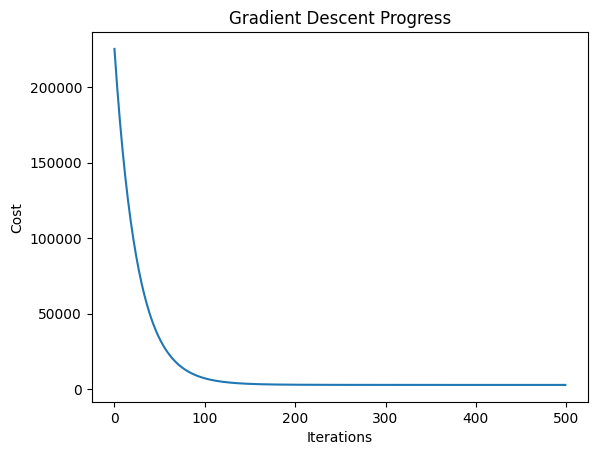

In [16]:
# Plot gradient descent progress.
plt.plot(range(num_iterations), cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Gradient Descent Progress')
plt.show()

**Plot the Model Predictions**

In [17]:
# Generate different combinations of X and Y sets to build a predictions plane.
predictions_num = 10

# Find min and max values along X and Y axes.
x_min = x_train[:, 0].min();
x_max = x_train[:, 0].max();

y_min = x_train[:, 1].min();
y_max = x_train[:, 1].max();

# Generate predefined numbe of values for eaxh axis betwing correspondent min and max values.
x_axis = np.linspace(x_min, x_max, predictions_num)
y_axis = np.linspace(y_min, y_max, predictions_num)

# Create empty vectors for X and Y axes predictions
# We're going to find cartesian product of all possible X and Y values.
x_predictions = np.zeros((predictions_num * predictions_num, 1))
y_predictions = np.zeros((predictions_num * predictions_num, 1))

# Find cartesian product of all X and Y values.
x_y_index = 0
for x_index, x_value in enumerate(x_axis):
    for y_index, y_value in enumerate(y_axis):
        x_predictions[x_y_index] = x_value
        y_predictions[x_y_index] = y_value
        x_y_index += 1

# Predict Z value for all X and Y pairs.
z_predictions = linear_regression.predict(np.hstack((x_predictions, y_predictions)))

# Plot training data with predictions.

# Configure the plot with test dataset.
plot_predictions_trace = go.Scatter3d(
    x=x_predictions.flatten(),
    y=y_predictions.flatten(),
    z=z_predictions.flatten(),
    name='Prediction Plane',
    mode='markers',
    marker={
        'size': 1,
    },
    opacity=0.8,
    surfaceaxis=2,
)

plot_data = [plot_training_trace, plot_test_trace, plot_predictions_trace]
plot_figure = go.Figure(data=plot_data, layout=plot_layout)
plotly.offline.iplot(plot_figure)

Calculate the value of cost function for the training and test data set. The less this value is, the better.

In [18]:
train_cost = linear_regression.get_cost(x_train, y_train, regularization_param)
test_cost = linear_regression.get_cost(x_test, y_test, regularization_param)

print('Train cost: {:.2f}'.format(train_cost))
print('Test cost: {:.2f}'.format(test_cost))

Train cost: 2691.64
Test cost: 130.87


Let's now render the table of prediction values that our trained model does for unknown data (for test dataset).

In [19]:
test_predictions = linear_regression.predict(x_test)

test_predictions_table = pd.DataFrame({
    'Economy GDP per Capita': x_test[:, 0].flatten(),
    'Freedom': x_test[:, 1].flatten(),
    'Test Happiness Score': y_test.flatten(),
    'Predicted Happiness Score': test_predictions.flatten(),
    'Prediction Diff': (y_test - test_predictions).flatten()
})

test_predictions_table.head(10)

,Economy GDP per Capita,Freedom,Test Happiness Score,Predicted Happiness Score,Prediction Diff
0,1.375382,0.405989,7.213,6.626766,0.586233
1,1.546259,0.505741,6.993,7.260849,-0.267849
2,1.185295,0.494519,6.599,6.394492,0.204508
3,1.153184,0.412730,6.578,6.125830,0.452170
4,1.233748,0.550027,6.452,6.638845,-0.186845
5,1.291215,0.402265,6.084,6.422130,-0.338130
6,0.737299,0.447552,6.071,5.240893,0.830107
7,1.395067,0.256451,5.964,6.317941,-0.353941
8,0.833757,0.558733,5.823,5.728949,0.094051
9,1.130777,0.418272,5.822,6.086844,-0.264844


## Polynomial Regression (Non-Linear)

Is a form of regression analysis in which the relationship between the independent variable `x` and the dependent variable `y` is modelled as an `nth` degree polynomial in `x`. Although polynomial regression fits a nonlinear model to the data, as a statistical estimation problem it is linear, in the sense that the regression function `E(y|x)` is linear in the unknown parameters that are estimated from the data. For this reason, polynomial regression is considered to be a special case of multiple linear regression.

- `Demo Project`: In this example we will train our model to imitate an artificial non-linear equation.

**Load Data**

In [20]:
df = pd.read_csv('non-linear-regression-x-y.csv')

# Fetch training set and labels.
x = df['x'].values.reshape((df.shape[0],1))
y = df['y'].values.reshape((df.shape[0],1))

df.head()

,y,x
0,97.58776,1.0
1,97.76344,2.0
2,96.56705,3.0
3,92.52037,4.0
4,91.15097,5.0


**Plot the Data**

Lets visualize the training and test datasets to see the shape of the data.

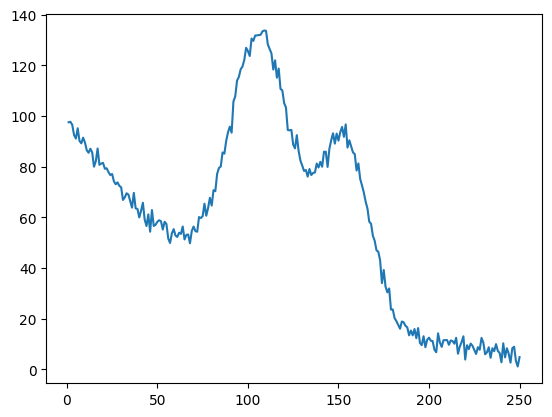

In [21]:
plt.plot(x, y)
plt.show()

**Initialize and Train Linear Regression Model**

In [22]:
# Set up linear regression parameters.
num_iterations = 50000  # Number of gradient descent iterations.
regularization_param = 0  # Helps to fight model overfitting.
learning_rate = 0.02  # The size of the gradient descent step.
polynomial_degree = 15  # The degree of additional polynomial features.
sinusoid_degree = 15  # The degree of sinusoid parameter multipliers of additional features.
normalize_data = True  # Flag that indicates that data needs to be normalized before training.

# Init linear regression instance.
linear_regression = LinearRegression(x, y, polynomial_degree, sinusoid_degree, normalize_data)

# Train linear regression.
(theta, cost_history) = linear_regression.train(
    learning_rate,
    regularization_param,
    num_iterations
)

# Print training results.
print('Initial cost: {:.2f}'.format(cost_history[0]))
print('Optimized cost: {:.2f}'.format(cost_history[-1]))

# Print model parameters
theta_table = pd.DataFrame({'Model Parameters': theta.flatten()})
theta_table

Initial cost: 137723281.24
Optimized cost: 2189884.51


,Model Parameters
0,60.531874
1,-3.730982
2,-3.265008
3,-4.293987
4,-3.048819
...,...
147,0.052387
148,0.052387
149,0.052387
150,0.052387


**Analyse Gradient Descent Progress**

The plot below illustrates how the cost function value changes over each iteration.

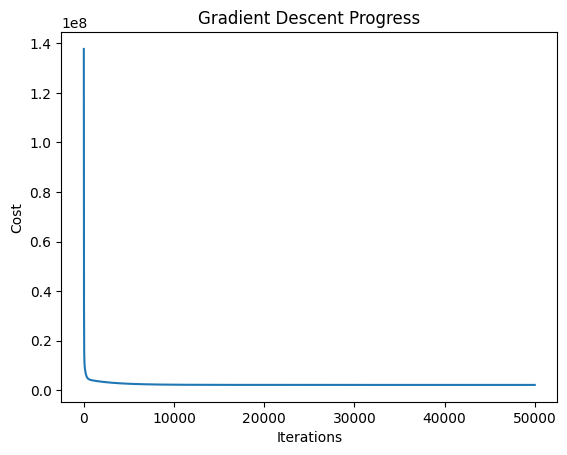

In [23]:
# Plot gradient descent progress.
plt.plot(range(num_iterations), cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Gradient Descent Progress')
plt.show()

**Plot the Model Predictions**

You may see from the plot how well our model predicts the training set examples.

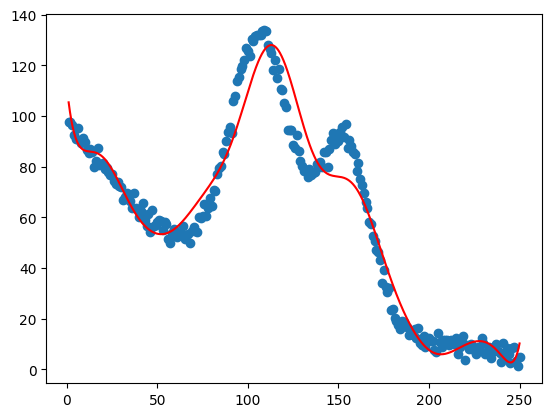

In [24]:
# Get model predictions for the trainint set.
predictions_num = 1000
x_predictions = np.linspace(x.min(), x.max(), predictions_num).reshape(predictions_num, 1);
y_predictions = linear_regression.predict(x_predictions)

# Plot training data with predictions.
plt.scatter(x, y, label='Training Dataset')
plt.plot(x_predictions, y_predictions, 'r', label='Prediction')
plt.show()